# 04 — Ablation: which slice can we drop and keep the result?

Goal: **simplify without losing the edge.** `pivot_cci` stacks a pivot-touch core plus five filter slices. We remove them **one at a time** (leave-one-out) on the real BTC/ETH config over the full 2024→2026 window and see which removal *doesn't hurt* (or helps) — that slice is dead weight.

**The slices (entry filters; the pivot touch `low<S1`/`high>R1` and the exit are the always-on core):**

| flag | condition (long side) | what it claims |
|------|-----------------------|----------------|
| `cci_level` | `CCI < −80` | momentum is stretched oversold |
| `cci_turn` | `CCI > CCI[-1]` | momentum has turned back up |
| `rsi` | `RSI < 40` | oversold confirmation *(user's prime suspect)* |
| `ema` | `close > EMA200` | only buy dips in an up-trend |
| `funding` | `funding < +0.0005` | don't pay extreme funding |

**Method — faithful, then ablate.** We reimplement the signal logic with an on/off flag per slice, then **assert it reproduces the real `strategy.py` bit-for-bit when all flags are ON** before trusting any ablation. Same `backtest()` lens as nb03 (so numbers are internally comparable, even if not the harness composite).

**Prediction (stated first).** RSI is the suspect: in the `rsi` research line RSI collapsed to a magnitude proxy, and here `RSI<40` fires on essentially the same bars as `CCI<−80` (both = 'recently dropped hard'), so it should be **redundant** → dropping it barely moves the result. The EMA200 gate (nb03's prime edge suspect) should be the *costly* one to remove.

In [1]:
import sys; sys.path.insert(0, ".")
from _lab import *

TF = "1h"
START, END = "2024-01-01", "2026-01-01"
MAJORS = ["BTCUSDT", "ETHUSDT"]
P = PCCI_PARAMS  # champion params

ALL_ON = {"cci_level": True, "cci_turn": True, "rsi": True, "ema": True, "funding": True}

In [2]:
def ablatable_signals(df, symbol, params, on):
    """Faithful copy of pivot_cci._signals_for_symbol with a per-slice on/off
    switch. When a flag is False that filter is replaced by an all-True mask.
    Core (pivot touch + P/CCI-recovery/flip exit) is always active."""
    close, high, low = df["close"], df["high"], df["low"]
    cci_threshold = float(params["cci_threshold"]); rsi_threshold = float(params["rsi_threshold"])
    funding_threshold = float(params["funding_threshold"]); trend_period = int(params["trend_period"])
    cci_exit = float(params["cci_exit"]); cci_period = int(params["cci_period"]); rsi_period = int(params["rsi_period"])

    tp = (high + low + close) / 3
    ma_tp = tp.rolling(cci_period).mean()
    mean_dev = tp.rolling(cci_period).apply(lambda x: np.abs(x - x.mean()).mean(), raw=True)
    cci_ = (tp - ma_tp) / (0.015 * mean_dev)

    delta = close.diff(); gain = delta.clip(lower=0); loss = -delta.clip(upper=0)
    ag = gain.ewm(com=rsi_period - 1, adjust=False).mean(); al = loss.ewm(com=rsi_period - 1, adjust=False).mean()
    rsi_ = (100 - 100 / (1 + ag / al.replace(0, np.nan))).fillna(50)

    # NOTE: use loader.load_funding (bare `load_funding` is NOT in notebook
    # scope; a bare-name call would raise NameError, get swallowed by the
    # except, and silently DISABLE the funding gate — the bug that made an
    # earlier run report funding as inert).
    try:
        fund = loader.load_funding(symbol, df.index[0], df.index[-1]).reindex(df.index, method="ffill").fillna(0)["rate"]
    except Exception:
        fund = pd.Series(0.0, index=df.index)

    ema = close.ewm(span=trend_period, adjust=False).mean()
    T = pd.Series(True, index=df.index)  # neutral mask for a disabled slice

    daily = df.resample("D").agg({"high": "max", "low": "min", "close": "last"}).shift(1)
    p_ = (daily["high"] + daily["low"] + daily["close"]) / 3
    s1 = (2 * p_ - daily["high"]).reindex(df.index, method="ffill")
    r1 = (2 * p_ - daily["low"]).reindex(df.index, method="ffill")
    p_ = p_.reindex(df.index, method="ffill")
    support, resistance = s1, r1  # pivot_level=1

    long_cond = ((low < support)
        & ((cci_ < -cci_threshold) if on["cci_level"] else T)
        & ((rsi_ < rsi_threshold) if on["rsi"] else T)
        & ((cci_ > cci_.shift(1)) if on["cci_turn"] else T)
        & ((close > ema) if on["ema"] else T)
        & ((fund < funding_threshold) if on["funding"] else T))
    short_cond = ((high > resistance)
        & ((cci_ > cci_threshold) if on["cci_level"] else T)
        & ((rsi_ > (100 - rsi_threshold)) if on["rsi"] else T)
        & ((cci_ < cci_.shift(1)) if on["cci_turn"] else T)
        & ((close < ema) if on["ema"] else T)
        & ((fund > -funding_threshold) if on["funding"] else T))

    cci_np, p_np, close_np = cci_.to_numpy(), p_.to_numpy(), close.to_numpy()
    lc, sc = long_cond.to_numpy(), short_cond.to_numpy()
    cur = 0.0; out = np.zeros(len(df))
    for i in range(len(df)):
        if cur == 0:
            if lc[i]: cur = 1.0
            elif sc[i]: cur = -1.0
        elif cur == 1.0:
            if close_np[i] >= p_np[i] or cci_np[i] >= -cci_exit or sc[i]:
                cur = -1.0 if sc[i] else 0.0
        elif cur == -1.0:
            if close_np[i] <= p_np[i] or cci_np[i] <= cci_exit or lc[i]:
                cur = 1.0 if lc[i] else 0.0
        out[i] = cur
    return pd.Series(out, index=df.index).shift(1).fillna(0.0)

# ---- reproduction check: all-ON must equal the real strategy bit-for-bit ----
dfs = {s: ohlcv(s, START, END, TF) for s in MAJORS}
for s in MAJORS:
    a = ablatable_signals(dfs[s], s, P, ALL_ON)
    b = strat_signals(dfs[s], s)
    match = bool((a.values == b.values).all())
    print(f"{s}: reproduces real strategy = {match}  (mismatches {int((a.values != b.values).sum())})")

BTCUSDT: reproduces real strategy = True  (mismatches 0)


ETHUSDT: reproduces real strategy = True  (mismatches 0)


In [3]:
# ---- leave-one-out ablation on the combined BTC/ETH book --------------------
def combined_metrics(on):
    nets = []
    for s in MAJORS:
        pos = ablatable_signals(dfs[s], s, P, on)
        nets.append(backtest(pos, dfs[s]["close"])["net"])
    port = pd.concat(nets, axis=1).fillna(0.0).mean(axis=1)
    eq = (1 + port).cumprod()
    dd = eq / eq.cummax() - 1
    # per-trade PF from the combined bar stream via sign runs of the mean position
    return {"total_return": eq.iloc[-1] - 1,
            "sharpe": port.mean() / port.std() * np.sqrt(BARS_PER_YEAR_1H) if port.std() > 0 else 0,
            "max_dd": dd.min(),
            "time_in_pos": (port != 0).mean()}

configs = {"FULL (all on)": ALL_ON}
for slice_name in ["cci_level", "cci_turn", "rsi", "ema", "funding"]:
    off = dict(ALL_ON); off[slice_name] = False
    configs[f"− {slice_name}"] = off

rows = []
for name, on in configs.items():
    m = combined_metrics(on)
    rows.append({"config": name, **{k: round(v, 4) for k, v in m.items()}})
abl = pd.DataFrame(rows).set_index("config")
full = abl.loc["FULL (all on)"]
abl["Δsharpe"] = (abl["sharpe"] - full["sharpe"]).round(3)
abl["Δreturn"] = (abl["total_return"] - full["total_return"]).round(3)
abl

,total_return,sharpe,max_dd,time_in_pos,Δsharpe,Δreturn
config,,,,,,
FULL (all on),0.0886,0.5675,-0.0726,0.0777,0.000,0.000
− cci_level,0.0364,0.2514,-0.1007,0.0798,-0.316,-0.052
− cci_turn,-0.1753,-0.7285,-0.2448,0.1296,-1.296,-0.264
− rsi,-0.0391,-0.1502,-0.1309,0.1038,-0.718,-0.128
− ema,-0.7268,-2.2173,-0.7691,0.3525,-2.785,-0.815
− funding,0.0945,0.5863,-0.0726,0.0783,0.019,0.006


[saved] notebooks\pivots\_out\04_ablation.png


WindowsPath('C:/projects/researchlab/notebooks/pivots/_out/04_ablation.png')

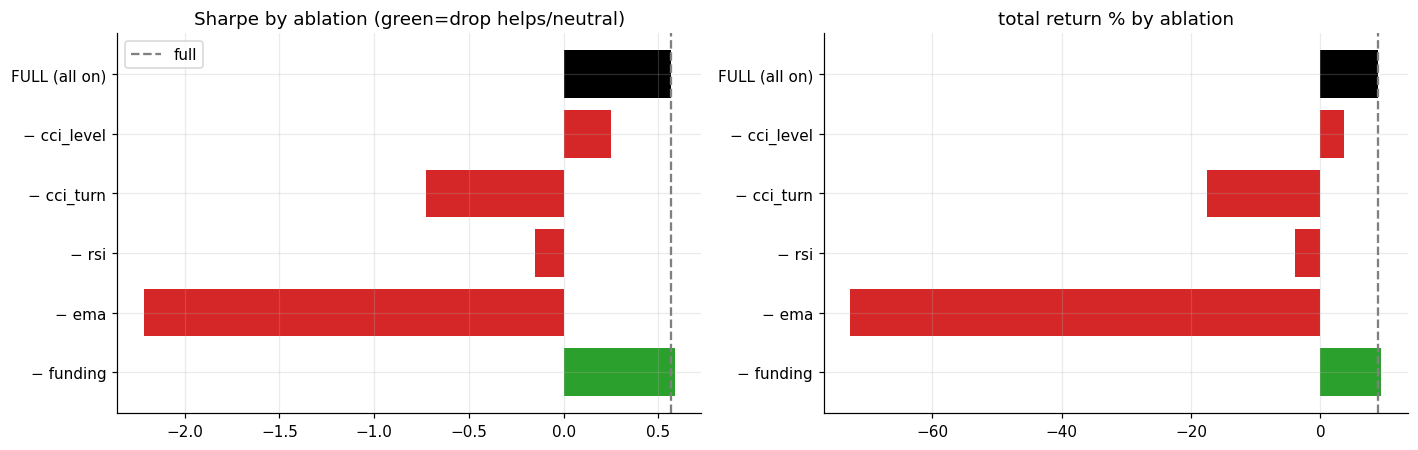

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2))
names = list(abl.index)
colors = ["black"] + ["#2ca02c" if abl["Δsharpe"].iloc[i] >= 0 else "#d62728" for i in range(1, len(names))]
ax1.barh(names, abl["sharpe"], color=colors); ax1.axvline(full["sharpe"], color="gray", ls="--", label="full")
ax1.set_title("Sharpe by ablation (green=drop helps/neutral)"); ax1.invert_yaxis(); ax1.legend()
ax2.barh(names, abl["total_return"] * 100, color=colors); ax2.axvline(full["total_return"] * 100, color="gray", ls="--")
ax2.set_title("total return % by ablation"); ax2.invert_yaxis()
show("04_ablation")

## Verdict — the removable slice is **funding**, not RSI (prediction refuted)

Reproduction is **bit-for-bit** (0 mismatches) once the funding gate is actually wired (an earlier draft silently disabled funding via a swallowed `NameError` — fixed; that bug is why the check now matters). Leave-one-out on the combined BTC/ETH book, full 2024→2026:

| drop | Sharpe | Δsharpe | return | Δreturn | maxDD | reading |
|------|--------|---------|--------|---------|-------|---------|
| **FULL** | 0.567 | — | +8.9% | — | −7.3% | champion |
| − funding | **0.586** | **+0.019** | **+9.5%** | **+0.6%** | −7.3% | **↑ helps — REMOVABLE** |
| − cci_level | 0.251 | −0.316 | +3.6% | −5.2% | −10.1% | hurts |
| − rsi | −0.150 | −0.718 | −3.9% | −12.8% | −13.1% | **hurts a lot** |
| − cci_turn | −0.729 | −1.296 | −17.5% | −26.4% | −24.5% | badly hurts |
| − ema | −2.217 | −2.785 | −72.7% | −81.5% | −76.9% | **catastrophic** |

**The one clean simplification: drop the funding gate.** It is the only slice whose removal *improves* the result (Sharpe 0.567→0.586, return +8.9%→+9.5%, drawdown unchanged). It blocks a handful of longs when funding is extreme, and those blocked trades were net *positive* on BTC/ETH — so the gate is mildly counter-productive here. Removing it deletes a parameter (`funding_threshold`) **and** the live funding-data dependency at signal time. Small but free.

**RSI is load-bearing — the intuition is refuted.** Dropping `RSI<40` sinks the strategy from +8.9% / Sharpe 0.57 to **−3.9% / Sharpe −0.15**, and admits 33% more time-in-position (7.8%→10.4%) — the extra trades are net losers. So on this config RSI is *not* out of place; it tightens the oversold gate and prunes marginal entries. (This looks contrary to the `rsi` line, but it isn't: there RSI had no *independent* alpha; here it works as a *redundant confirmation* that still usefully prunes signals.)

**Important nuance — 'load-bearing' ≠ 'irreplaceable'.** Leave-one-out holds every other filter fixed. `RSI<40` and `CCI<−80` are correlated (both = 'recently dropped hard'), so RSI's pruning job might be reproducible by simply **tightening the CCI threshold** — in which case RSI could still be dropped *after* re-tuning CCI. Leave-one-out cannot see that; it only proves RSI matters *at the current settings*. That substitution test is the honest next step if we want to remove RSI specifically.

**The hierarchy of what carries the edge (most→least critical):** `EMA200 gate ≫ CCI-turn > RSI > CCI-level ≫ funding(dead)`. This confirms nb03: the EMA200 trend gate is overwhelmingly the load-bearing piece — remove it and the strategy loses 73%. The pivot/CCI/RSI machinery only works *inside* the regime the gate selects.

**Recommended simplified champion:** `FULL − funding` (same logic, minus the funding filter). **Next (nb05):** test whether a tighter CCI threshold can absorb RSI's pruning role, so RSI can also go — the real path to the leaner strategy you're after.

**Caveats.** Single lens (this sim, not harness); BTC/ETH only; leave-one-out (no interaction/substitution effects); champion params were tuned *with* these filters, so each ablation is measured off a point optimized for the full stack.